In [8]:
import time

from spacerocks.assist import SpiceSimulation
from spacerocks.nbody import Simulation
from spacerocks.spice import SpiceKernel
from spacerocks.time import Time
from spacerocks import SpaceRock

kernel = SpiceKernel()
kernel.load_spk("/Users/kjnapier/data/spice/de441_part-2.bsp")
kernel.load_spk("/Users/kjnapier/data/spice/sb441-n16.bsp")

import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [9]:
epoch = Time.now()
rock = SpaceRock.from_horizons("arrokoth", epoch=epoch, reference_plane="J2000", origin="SSB")

In [35]:
assist_sim = SpiceSimulation.giants(epoch, kernel)
assist_sim.add(rock)

nbody_sim = Simulation.giants(epoch, "J2000", "SSB", kernel)
nbody_sim.add(rock)

In [36]:
t = Time(5373119.5 + 365 * 7000, "tdb", "jd")

In [37]:
t.calendar()

'8 May 16994'

In [38]:
t0 = time.time()
assist_sim.integrate(t, kernel)
t1 = time.time()
print("Assist simulation time:", t1 - t0)

Assist simulation time: 0.029710769653320312


In [39]:
assist_sim.timestep

2912.719610410179

In [40]:
t0 = time.time()
nbody_sim.integrate(t)
t1 = time.time()
print("Assist simulation time:", t1 - t0)

Assist simulation time: 0.4755418300628662


In [41]:
nbody_sim.timestep

104.36905506166507

In [ ]:
nbody_sim

In [98]:
t0 = time.time()
for idx in range(47468):
    assist_sim.step(kernel)
t1 = time.time()
print(f"Assist simulation took {t1 - t0:.2f} seconds")

Assist simulation took 2.22 seconds


In [100]:
assist_sim.epoch

AttributeError: 'builtins.SpiceSimulation' object has no attribute 'epoch'

In [62]:
15000 / 2.19

6849.315068493151

In [64]:
(100_000.0 / 6849.315068493151)

14.6

In [55]:


(10_000_000.0 / 6849.315068493151) / 60

24.333333333333332

In [47]:
nsteps = 0
while True:
    assist_sim.step(kernel)
    nsteps += 1


thread '<unnamed>' panicked at /Users/kjnapier/spacerocks/src/assist/integrators/ias15.rs:160:124:
called `Result::unwrap()` on an `Err` value: Coverage


PanicException: called `Result::unwrap()` on an `Err` value: Coverage

In [48]:
nsteps

47468

In [23]:
nsteps

1

In [5]:
assist_sim.timestep

58.159461231234125

In [4]:
%%time
for i in range(1000):
    assist_sim.step(kernel)

CPU times: user 45.1 ms, sys: 2.46 ms, total: 47.5 ms
Wall time: 46.8 ms


In [5]:
%%time
for i in range(1000):
    nbody_sim.step()

CPU times: user 73.7 ms, sys: 1.33 ms, total: 75 ms
Wall time: 74.3 ms


In [6]:
dts = []
nbody_dts = []
for _ in range(1000):
    assist_sim.step(kernel)
    dt = assist_sim.timestep
    dts.append(dt)
    nbody_sim.step()
    dt = nbody_sim.timestep
    nbody_dts.append(dt)

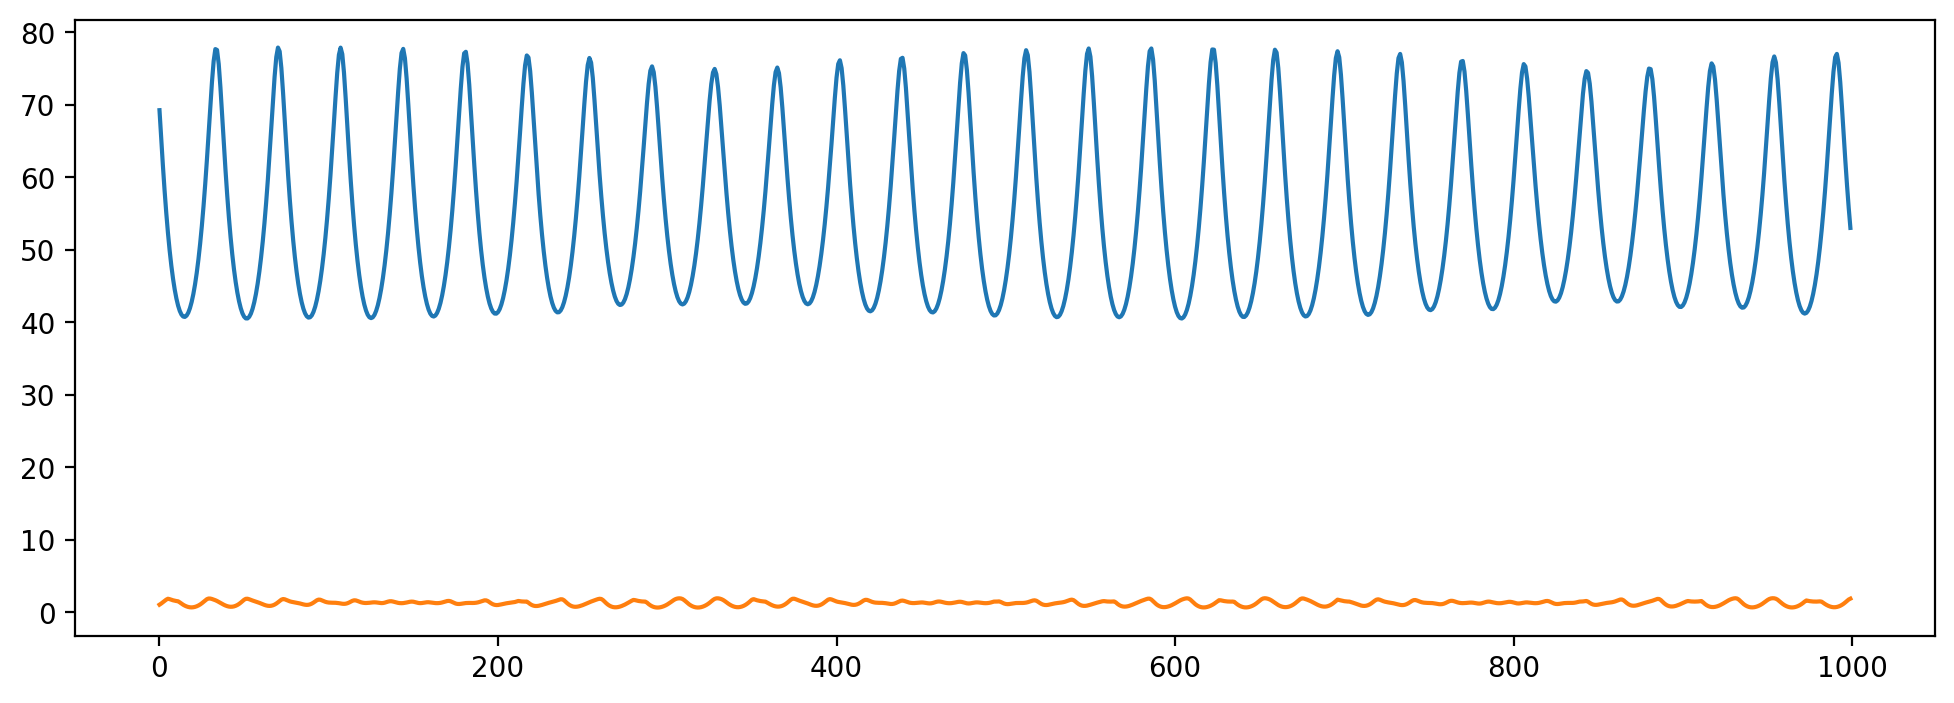

In [25]:
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.plot(dts, label="Assist")
ax.plot(nbody_dts, label="N-body")

In [137]:
assist_sim = SpiceSimulation.horizons(epoch, kernel)
assist_sim.add(rock)

nbody_sim = Simulation.horizons(epoch, "J2000", "SSB", kernel)
nbody_sim.add(rock)

In [138]:
t0 = time.time()
for idx in range(1000):
    assist_sim.integrate(epoch + idx, kernel)
t1 = time.time()
print(f"time: {1000.0 * (t1 - t0):.3f} ms")

time: 1.712 ms


In [10]:
t0 = time.time()
for idx in range(1000):
    nbody_sim.integrate(epoch + idx)
t1 = time.time()
print(f"time: {1000.0 * (t1 - t0):.3f} ms")

time: 153.536 ms


In [11]:
import numpy as np

In [12]:
round_trip_times = np.logspace(0, 5, 25)
epoch = Time.now()
rock = SpaceRock.from_horizons("holman", epoch=epoch, reference_plane="J2000", origin="SSB")
M_PER_AU = 149597870700.0

In [13]:
offsets = []
for dt in round_trip_times:
    
    assist_sim = SpiceSimulation.horizons(epoch, kernel)
    assist_sim.add(rock)
    x0, y0, z0 = assist_sim.particles[0].position

    assist_sim.integrate(epoch + dt, kernel)
    assist_sim.integrate(epoch, kernel)

    xf, yf, zf = assist_sim.particles[0].position

    dx = (x0 - xf) * M_PER_AU / 1000
    dy = (y0 - yf) * M_PER_AU / 1000
    dz = (z0 - zf) * M_PER_AU / 1000
    offset = (dx**2 + dy**2 + dz**2)**0.5
    offsets.append(offset)

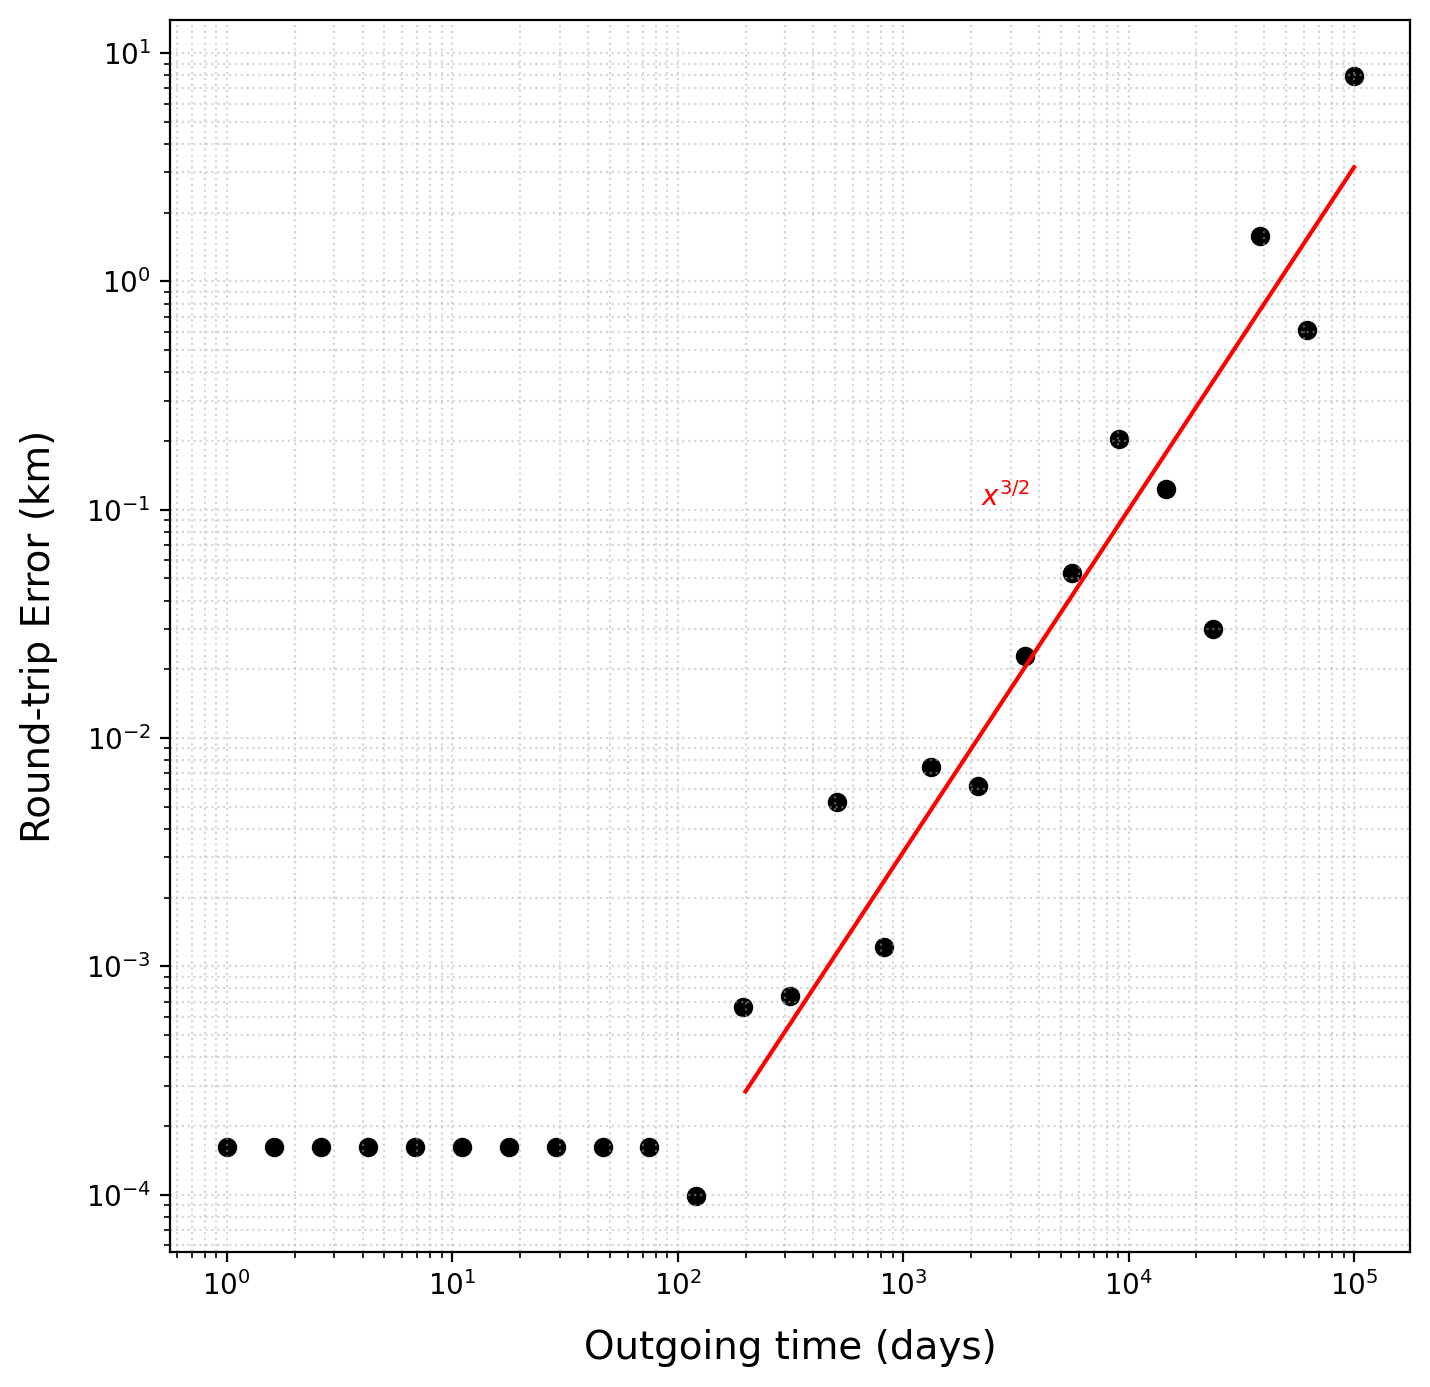

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(round_trip_times, offsets, label="Assist", color='black')
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Outgoing time (days)", fontsize=14, labelpad=10)
ax.set_ylabel("Round-trip Error (km)", fontsize=14, labelpad=10)

# plot a power law like x^1.5
x = np.linspace(200, 1e5, 100)
y = 0.0000001 * (x)**1.5
ax.plot(x, y, label="x^1.5", color="red")
ax.text(x[2], y[10], r"$x^{3/2}$", color="red")

ax.grid(which="both", linestyle=":", alpha=0.5)
# ax.set_ylim(1e-7, 20)